In [2]:
#Task 1:
import pandas as pd
df = pd.read_excel("Online Retail.xlsx")
df.to_csv("Online Retail.csv",index = False)


In [3]:


# Display first rows
print(df.head())

# Display last rows
print(df.tail())

# Dataset shape
print(df.shape)

# Column names
print(df.columns)

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899     CHILDREN'S A

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
#Task 2 :
# Remove rows with missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove negative quantities
df = df[df["Quantity"] > 0]

# Remove invalid prices
df = df[df["UnitPrice"] > 0]

# Check final dataset
print(df.shape)

# Check missing values
print(df.isnull().sum())

# Check duplicates
print(df.duplicated().sum())


(392692, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
0


In [5]:
#Task 3:
# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

# Extract date features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

# Customer Segment
df["Customer Segment"] = df["TotalPrice"].apply(
    lambda x: "High Value" if x > 1000 else
              "Medium Value" if x > 300 else
              "Low Value"
)

# Order Size
df["Order Size"] = df["Quantity"].apply(
    lambda x: "Large" if x >= 20 else
              "Medium" if x >= 10 else
              "Small"
)

# Day Type
df["Day Type"] = df["InvoiceDate"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Display dataset
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

   Year  Month  Day  Hour Customer Segment Order Size Day Type  
0  2010     12    1     8        Low Value   

In [6]:
#TASK 4:
# Dataset overview
print(df.info())

# Statistical summary
print(df.describe())

# Categorical summary
print(df.describe(include="object"))

# Unique values
print(df["Country"].unique())

# Number of unique countries
print(df["Country"].nunique())

# Value counts
print(df["Country"].value_counts())

print(df["Customer Segment"].value_counts())

print(df["Order Size"].value_counts())

# Groupby analysis
country_sales = df.groupby("Country")["TotalPrice"].sum()
print(country_sales)

monthly_sales = df.groupby("Month")["TotalPrice"].sum()
print(monthly_sales)

product_sales = df.groupby("Description")["TotalPrice"].sum()
print(product_sales.sort_values(ascending=False).head(10))

# Multiple aggregation
print(
    df.groupby("Country").agg({
        "TotalPrice": ["sum", "mean"],
        "Quantity": ["sum", "mean"]
    })
)

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392692 non-null  object        
 1   StockCode         392692 non-null  object        
 2   Description       392692 non-null  object        
 3   Quantity          392692 non-null  int64         
 4   InvoiceDate       392692 non-null  datetime64[ns]
 5   UnitPrice         392692 non-null  float64       
 6   CustomerID        392692 non-null  float64       
 7   Country           392692 non-null  object        
 8   TotalPrice        392692 non-null  float64       
 9   Year              392692 non-null  int32         
 10  Month             392692 non-null  int32         
 11  Day               392692 non-null  int32         
 12  Hour              392692 non-null  int32         
 13  Customer Segment  392692 non-null  object        
 14  Order Siz

In [7]:
#TASK 5:
# Customer-wise sales
customer_sales = df.groupby("CustomerID")["TotalPrice"].sum()
print(customer_sales)

# Country-wise sales
country_sales = df.groupby("Country")["TotalPrice"].sum()
print(country_sales)

# Product-wise quantity
product_quantity = df.groupby("Description")["Quantity"].sum()
print(product_quantity)

# Top customers
top_customers = df.groupby("CustomerID")["TotalPrice"] \
                  .sum() \
                  .sort_values(ascending=False)

print(top_customers.head(10))

# Top countries
top_countries = df.groupby("Country")["TotalPrice"] \
                  .sum() \
                  .sort_values(ascending=False)

print(top_countries.head(10))

# Pivot table
pivot_table = df.pivot_table(
    values="TotalPrice",
    index="Country",
    columns="Month",
    aggfunc="sum",
    fill_value=0
)

print(pivot_table)

# Customer summary
customer_summary = df.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "Quantity": "sum",
    "InvoiceNo": "count"
})

print(customer_summary.head())

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2045.53
18287.0     1837.28
Name: TotalPrice, Length: 4338, dtype: float64
Country
Australia                138453.810
Austria                   10198.680
Bahrain                     548.400
Belgium                   41196.340
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20440.540
Cyprus                    13502.850
Czech Republic              826.740
Denmark                   18955.340
EIRE                     265262.460
European Community         1300.250
Finland                   22546.080
France                   208934.310
Germany                  228678.400
Greece                     4760.520
Iceland                    4310.000
Israel                     7215.840
Italy                     17483.240
Japan                     3741

In [8]:
#TASk 6:
# Select columns
stats_df = df[["Quantity", "UnitPrice", "TotalPrice"]]

# Mean
print("Mean")
print(stats_df.mean())

# Median
print("\nMedian")
print(stats_df.median())

# Mode
print("\nMode")
print(stats_df.mode())

# Standard deviation
print("\nStandard Deviation")
print(stats_df.std())

# Variance
print("\nVariance")
print(stats_df.var())

# Percentiles
print("\nPercentiles")
print(stats_df.quantile([0.25, 0.50, 0.75]))

# Full statistical summary
print("\nDescribe")
print(stats_df.describe())

Mean
Quantity      13.119702
UnitPrice      3.125914
TotalPrice    22.631500
dtype: float64

Median
Quantity       6.00
UnitPrice      1.95
TotalPrice    12.45
dtype: float64

Mode
   Quantity  UnitPrice  TotalPrice
0         1       1.25        15.0

Standard Deviation
Quantity      180.492832
UnitPrice      22.241836
TotalPrice    311.099224
dtype: float64

Variance
Quantity      32577.662399
UnitPrice       494.699251
TotalPrice    96782.727382
dtype: float64

Percentiles
      Quantity  UnitPrice  TotalPrice
0.25       2.0       1.25        4.95
0.50       6.0       1.95       12.45
0.75      12.0       3.75       19.80

Describe
            Quantity      UnitPrice     TotalPrice
count  392692.000000  392692.000000  392692.000000
mean       13.119702       3.125914      22.631500
std       180.492832      22.241836     311.099224
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
7

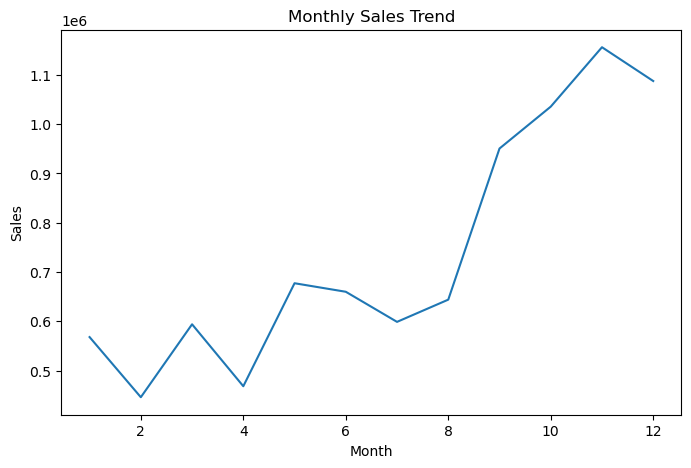

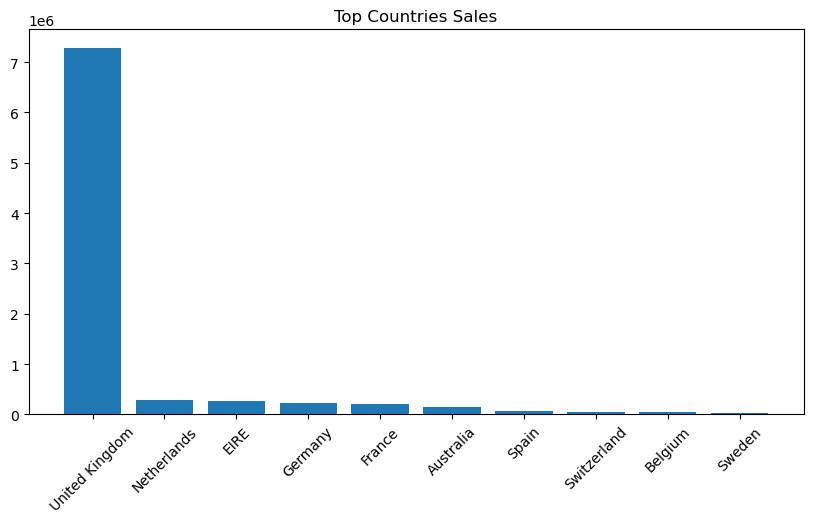

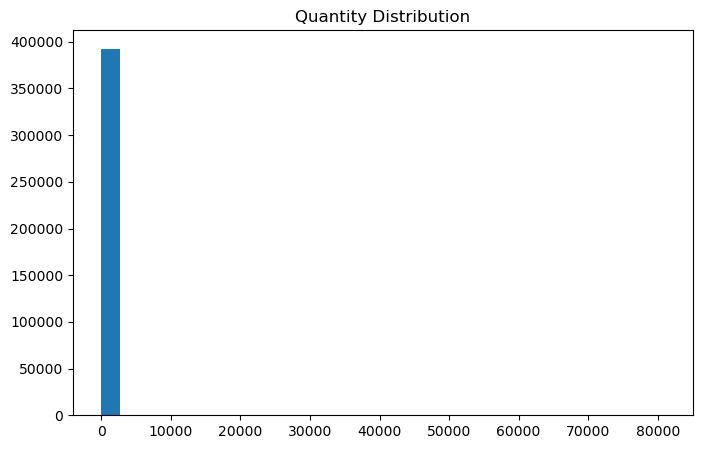

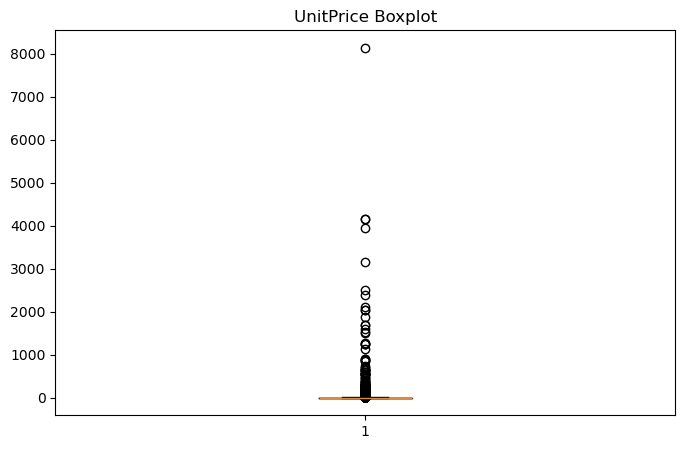

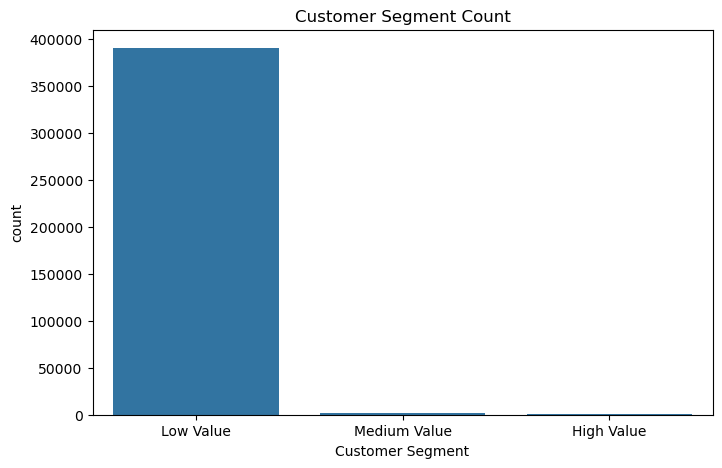

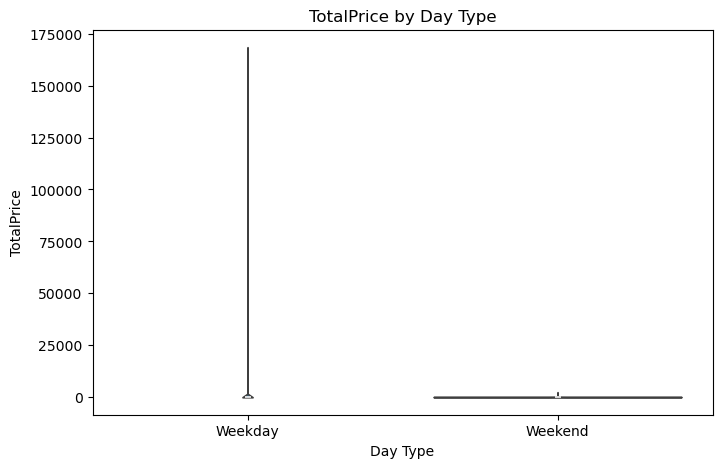

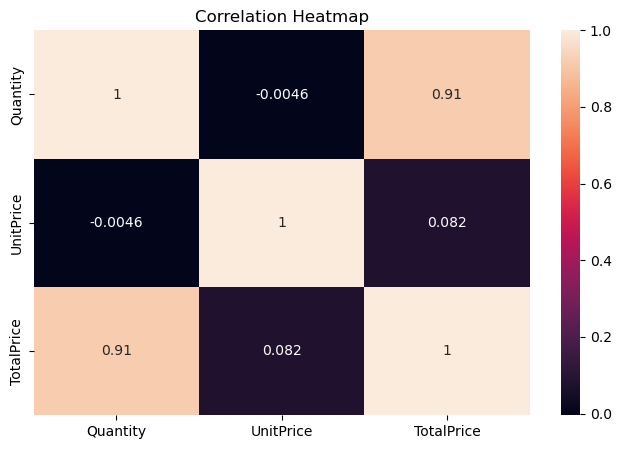

In [ ]:
#TASK 7:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 Line Chart
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# 2 Bar Chart
top_countries = df.groupby("Country")["TotalPrice"] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10)

plt.figure(figsize=(10,5))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top Countries Sales")
plt.xticks(rotation=45)
plt.show()

# 3 Histogram
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=30)
plt.title("Quantity Distribution")
plt.show()

# 4 Box Plot
plt.figure(figsize=(8,5))
plt.boxplot(df["UnitPrice"])
plt.title("UnitPrice Boxplot")
plt.show()

# 5 Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x="Customer Segment", data=df)
plt.title("Customer Segment Count")
plt.show()

# 6 Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(x="Day Type", y="TotalPrice", data=df)
plt.title("TotalPrice by Day Type")
plt.show()

# 7 Heatmap
plt.figure(figsize=(8,5))
corr = df[["Quantity", "UnitPrice", "TotalPrice"]].corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# 8 Pair Plot
sns.pairplot(df[["Quantity", "UnitPrice", "TotalPrice"]])
plt.show()

In [18]:
#TASK 8:
# Top country
top_country = df.groupby("Country")["TotalPrice"] \
                .sum() \
                .sort_values(ascending=False)

print(top_country.head(1))

# Best sales month
best_month = df.groupby("Month")["TotalPrice"] \
               .sum() \
               .sort_values(ascending=False)

print(best_month.head(1))

# Peak sales hour
peak_hour = df.groupby("Hour")["TotalPrice"] \
              .sum() \
              .sort_values(ascending=False)

print(peak_hour.head(1))

# Customer behavior
customer_behavior = df.groupby("CustomerID")["TotalPrice"].mean()

print(customer_behavior.head())

# Purchase frequency
purchase_frequency = df["CustomerID"].value_counts()

print(purchase_frequency.head())

# High-value customers
high_value_customers = df.groupby("CustomerID")["TotalPrice"] \
                         .sum() \
                         .sort_values(ascending=False)

print(high_value_customers.head(10))

# Top products
top_products = df.groupby("Description")["TotalPrice"] \
                 .sum() \
                 .sort_values(ascending=False)

print(top_products.head(10))

# Most sold products
most_sold_products = df.groupby("Description")["Quantity"] \
                       .sum() \
                       .sort_values(ascending=False)

print(most_sold_products.head(10))

# Country-wise customers
country_customers = df.groupby("Country")["CustomerID"] \
                      .nunique() \
                      .sort_values(ascending=False)

print(country_customers.head(10))

Country
United Kingdom    7285024.644
Name: TotalPrice, dtype: float64
Month
11    1156205.61
Name: TotalPrice, dtype: float64
Hour
12    1373695.39
Name: TotalPrice, dtype: float64
CustomerID
12346.0    77183.600000
12347.0       23.681319
12348.0       57.975484
12349.0       24.076027
12350.0       19.670588
Name: TotalPrice, dtype: float64
CustomerID
17841.0    7676
14911.0    5670
14096.0    5111
12748.0    4412
14606.0    2677
Name: count, dtype: int64
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: TotalPrice, dtype: float64
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                        